# Modeling - Churn Prediction

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
%matplotlib inline

X_train = joblib.load('data/warehouse/X_train_prepared.pkl')
y_train = joblib.load('data/warehouse/y_train.pkl')

print("Shape X_train:", X_train.shape)
print("Distribución target:\n", y_train.value_counts())
print("% Churn:", round(y_train.mean() * 100, 2), "%")

Shape X_train: (46439, 19)
Distribución target:
 Churn_400
0.0    42323
1.0     4116
Name: count, dtype: int64
% Churn: 8.86 %


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='roc_auc')
print("Logistic Regression — ROC-AUC:")
print(f"  Scores: {scores.round(3)}")
print(f"  Media: {scores.mean():.3f}  |  Std: {scores.std():.3f}")

Logistic Regression — ROC-AUC:
  Scores: [0.733 0.723 0.727 0.73  0.731]
  Media: 0.729  |  Std: 0.003


In [3]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

scores = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring='roc_auc')
print("Decision Tree — ROC-AUC:")
print(f"  Scores: {scores.round(3)}")
print(f"  Media: {scores.mean():.3f}  |  Std: {scores.std():.3f}")

Decision Tree — ROC-AUC:
  Scores: [0.547 0.547 0.553 0.557 0.551]
  Media: 0.551  |  Std: 0.004


In [4]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest_clf.fit(X_train, y_train)

scores = cross_val_score(forest_clf, X_train, y_train, cv=5, scoring='roc_auc')
print("Random Forest — ROC-AUC:")
print(f"  Scores: {scores.round(3)}")
print(f"  Media: {scores.mean():.3f}  |  Std: {scores.std():.3f}")

Random Forest — ROC-AUC:
  Scores: [0.738 0.73  0.73  0.74  0.74 ]
  Media: 0.736  |  Std: 0.005


In [5]:
from sklearn.model_selection import cross_validate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'],
                        return_train_score=True)
    results.append({
        'Modelo':           name,
        'Train ROC-AUC':    cv['train_roc_auc'].mean().round(3),
        'Val ROC-AUC':      cv['test_roc_auc'].mean().round(3),
        'Val F1':           cv['test_f1'].mean().round(3),
        'Val Precision':    cv['test_precision'].mean().round(3),
        'Val Recall':       cv['test_recall'].mean().round(3),
        'Std ROC-AUC':      cv['test_roc_auc'].std().round(3),
    })

df_results = pd.DataFrame(results).set_index('Modelo')
df_results['Overfitting?'] = df_results['Train ROC-AUC'] - df_results['Val ROC-AUC']
print(df_results.to_string())

/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda

                     Train ROC-AUC  Val ROC-AUC  Val F1  Val Precision  Val Recall  Std ROC-AUC  Overfitting?
Modelo                                                                                                       
Logistic Regression          0.731        0.729   0.000          0.000       0.000        0.003         0.002
Decision Tree                1.000        0.551   0.181          0.166       0.200        0.004         0.449
Random Forest                1.000        0.736   0.024          0.246       0.013        0.005         0.264


/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

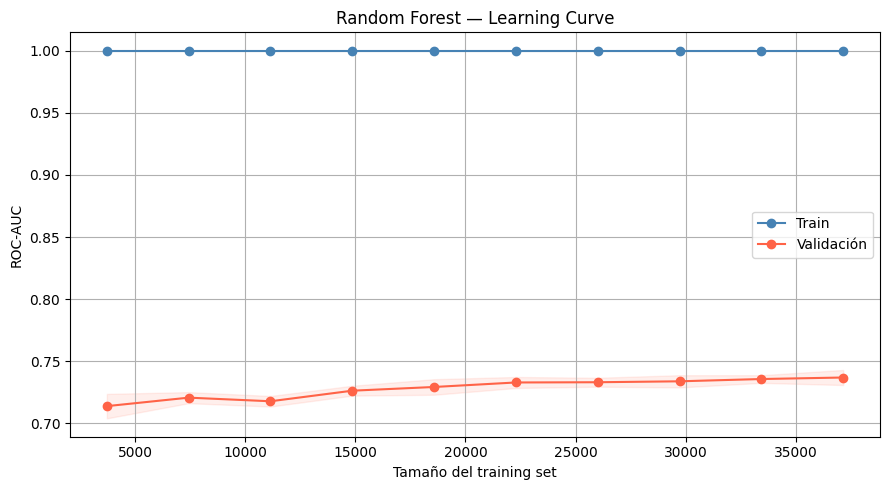

In [6]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    plt.figure(figsize=(9, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train', color='steelblue')
    plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', label='Validación', color='tomato')
    plt.fill_between(train_sizes,
                     train_scores.mean(1) - train_scores.std(1),
                     train_scores.mean(1) + train_scores.std(1), alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes,
                     val_scores.mean(1) - val_scores.std(1),
                     val_scores.mean(1) + val_scores.std(1), alpha=0.1, color='tomato')
    plt.xlabel("Tamaño del training set")
    plt.ylabel("ROC-AUC")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Cambia el modelo según los resultados anteriores
plot_learning_curve(forest_clf, X_train, y_train, title="Random Forest — Learning Curve")

In [7]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None],
}

rnd_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rnd_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", rnd_search.best_params_)
print("Mejor ROC-AUC (val):   ", round(rnd_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

Mejores hiperparámetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Mejor ROC-AUC (val):    0.7686


In [9]:
"""best_model = rnd_search.best_estimator_

# Necesitas los nombres de columnas del X_train original (antes del pipeline)
# Si usaste un DataFrame: feature_names = X_train_df.columns
# Si es numpy array, usa índices:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices], color='steelblue')
plt.xticks(range(20), indices, rotation=45)
plt.tight_layout()
plt.show()"""

'best_model = rnd_search.best_estimator_\n\n# Necesitas los nombres de columnas del X_train original (antes del pipeline)\n# Si usaste un DataFrame: feature_names = X_train_df.columns\n# Si es numpy array, usa índices:\nimportances = best_model.feature_importances_\nindices = np.argsort(importances)[::-1][:20]  # Top 20\n\nplt.figure(figsize=(10, 6))\nplt.title("Top 20 Feature Importances")\nplt.bar(range(20), importances[indices], color=\'steelblue\')\nplt.xticks(range(20), indices, rotation=45)\nplt.tight_layout()\nplt.show()'

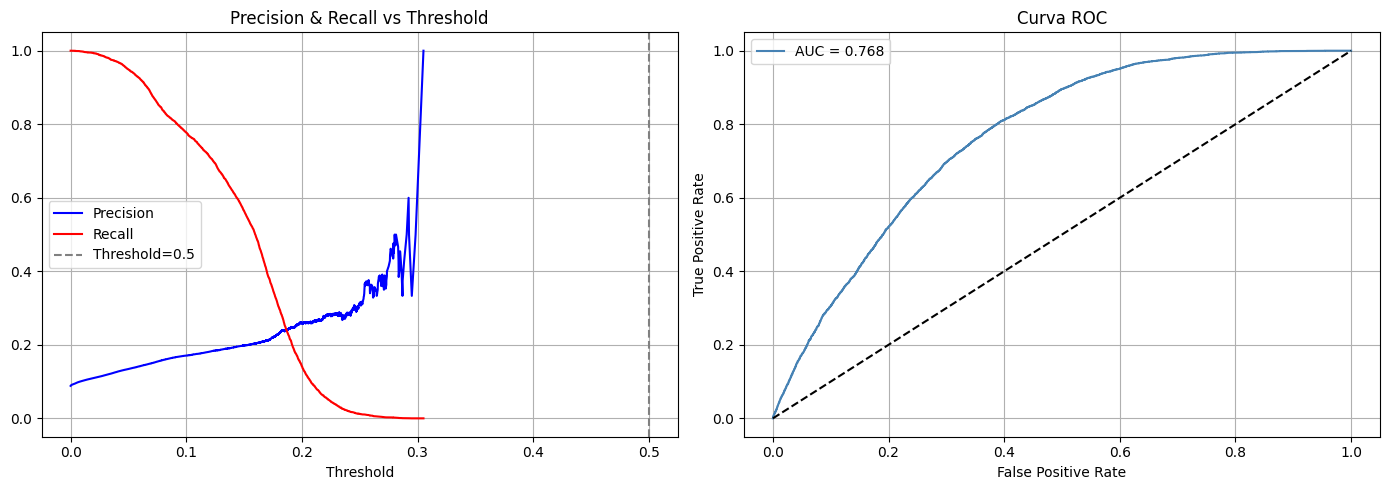

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_scores = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)
fpr, tpr, _ = roc_curve(y_train, y_scores)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision vs Recall vs Threshold
axes[0].plot(thresholds, precisions[:-1], 'b-', label='Precision')
axes[0].plot(thresholds, recalls[:-1],    'r-', label='Recall')
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Threshold=0.5')
axes[0].set_xlabel("Threshold")
axes[0].set_title("Precision & Recall vs Threshold")
axes[0].legend()
axes[0].grid(True)

# ROC Curve
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(best_model, 'data/warehouse/best_model.pkl')
joblib.dump(rnd_search, 'data/warehouse/rnd_search.pkl')
print("Modelo guardado ✓")